# Reporter Assay Analysis

Turns a reporter assay spreadsheet (e.g. luciferase) into tidy data, summary statistics and publication-style plots.

It compares **conditions** (transcription factors alone, in combination, and controls) across **doses**, with every replicate shown as a point on top of the bars.

**Expected spreadsheet layout** (one sheet, no extra header rows):

| Row | Content |
|-----|---------|
| 1 | Condition name, written above the first dose column of each condition |
| 2 | Dose for each column (e.g. `25 ng`, `50 ng`, `100 ng`) |
| 3+ | One row per biological replicate (blank cells are allowed) |

The included `data/example_reporter_assay.xlsx` is **synthetic data** generated for demonstration.

## 1. Settings

In [1]:
DATA_FILE = "data/example_reporter_assay.xlsx"   # path to your spreadsheet
BASELINE = "Reporter only"                       # condition used as the reference (fold change and statistics)
SAVE_FIGURES = True                              # save plots as PNG into FIGURE_DIR
FIGURE_DIR = "figures"

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="talk")

# error bars show mean ± SD; seaborn >= 0.12 uses `errorbar`, older versions use `ci`
SEABORN_NEW = tuple(int(x) for x in sns.__version__.split(".")[:2]) >= (0, 12)
ERRORBAR_SD = {"errorbar": "sd"} if SEABORN_NEW else {"ci": "sd"}
Path(FIGURE_DIR).mkdir(exist_ok=True)

## 2. Load and tidy the data

The two header rows are combined into one label per column, text values are converted to numbers, and the table is reshaped to *long* format (one row per measurement), which makes grouping and plotting straightforward.

In [3]:
def load_plate(path):
    raw = pd.read_excel(path, header=None)
    conditions = raw.iloc[0].ffill()          # fill the condition name across its dose columns
    doses = raw.iloc[1].astype(str).str.strip()
    values = raw.iloc[2:].apply(pd.to_numeric, errors="coerce").reset_index(drop=True)

    columns = pd.DataFrame({"condition": conditions.str.strip(), "dose": doses})
    # dose level = position of the dose within its condition (1 = lowest), so combinations
    # like "12.5 ng each" line up with the matching single-factor dose
    columns["dose_level"] = columns.groupby("condition").cumcount() + 1
    columns["label"] = columns["condition"] + " " + columns["dose"]

    values.columns = columns["label"]
    wide = values
    tidy = (values.rename_axis("replicate").reset_index()
                  .melt(id_vars="replicate", var_name="label", value_name="value")
                  .merge(columns, on="label")
                  .dropna(subset=["value"]))
    tidy["replicate"] += 1
    return wide, tidy, columns

wide, tidy, layout = load_plate(DATA_FILE)
wide

label,TF-A 25 ng,TF-A 50 ng,TF-A 100 ng,TF-B 25 ng,TF-B 50 ng,TF-B 100 ng,TF-A + TF-B 12.5 ng each,TF-A + TF-B 25 ng each,TF-A + TF-B 50 ng each,GFP control 25 ng,GFP control 50 ng,GFP control 100 ng,Reporter only 100 ng
0,1.800,2.229,2.914,1.426,1.916,2.322,2.205,3.729,5.164,0.957,0.921,0.889,0.997
1,1.843,2.313,3.211,1.559,1.759,1.963,2.332,3.415,5.024,0.996,1.010,1.031,1.071
2,1.761,2.210,NaN,1.543,1.896,2.119,2.217,3.882,4.073,1.009,0.968,0.889,0.953


In [4]:
missing = wide.isna().sum()
if missing.any():
    print("Missing replicates:")
    print(missing[missing > 0].to_string())

Missing replicates:
label
TF-A 100 ng    1


## 3. Summary statistics

Mean, standard deviation, number of replicates, and fold change relative to the baseline condition.

In [5]:
baseline_mean = tidy.loc[tidy["condition"] == BASELINE, "value"].mean()

summary = (tidy.groupby(["condition", "dose", "dose_level", "label"], sort=False)["value"]
               .agg(mean="mean", sd="std", n="count")
               .reset_index())
summary["fold_vs_baseline"] = summary["mean"] / baseline_mean
summary.round(3)

,condition,dose,dose_level,label,mean,sd,n,fold_vs_baseline
0,TF-A,25 ng,1,TF-A 25 ng,1.801,0.041,3,1.789
1,TF-A,50 ng,2,TF-A 50 ng,2.251,0.055,3,2.235
2,TF-A,100 ng,3,TF-A 100 ng,3.062,0.210,2,3.041
3,TF-B,25 ng,1,TF-B 25 ng,1.509,0.073,3,1.499
4,TF-B,50 ng,2,TF-B 50 ng,1.857,0.085,3,1.844
5,TF-B,100 ng,3,TF-B 100 ng,2.135,0.180,3,2.120
6,TF-A + TF-B,12.5 ng each,1,TF-A + TF-B 12.5 ng each,2.251,0.070,3,2.236
7,TF-A + TF-B,25 ng each,2,TF-A + TF-B 25 ng each,3.675,0.238,3,3.650
8,TF-A + TF-B,50 ng each,3,TF-A + TF-B 50 ng each,4.754,0.594,3,4.721
9,GFP control,25 ng,1,GFP control 25 ng,0.987,0.027,3,0.980


## 4. Overview: all conditions

Bars show the mean ± standard deviation; black points are individual replicates. The dashed line marks the baseline mean.

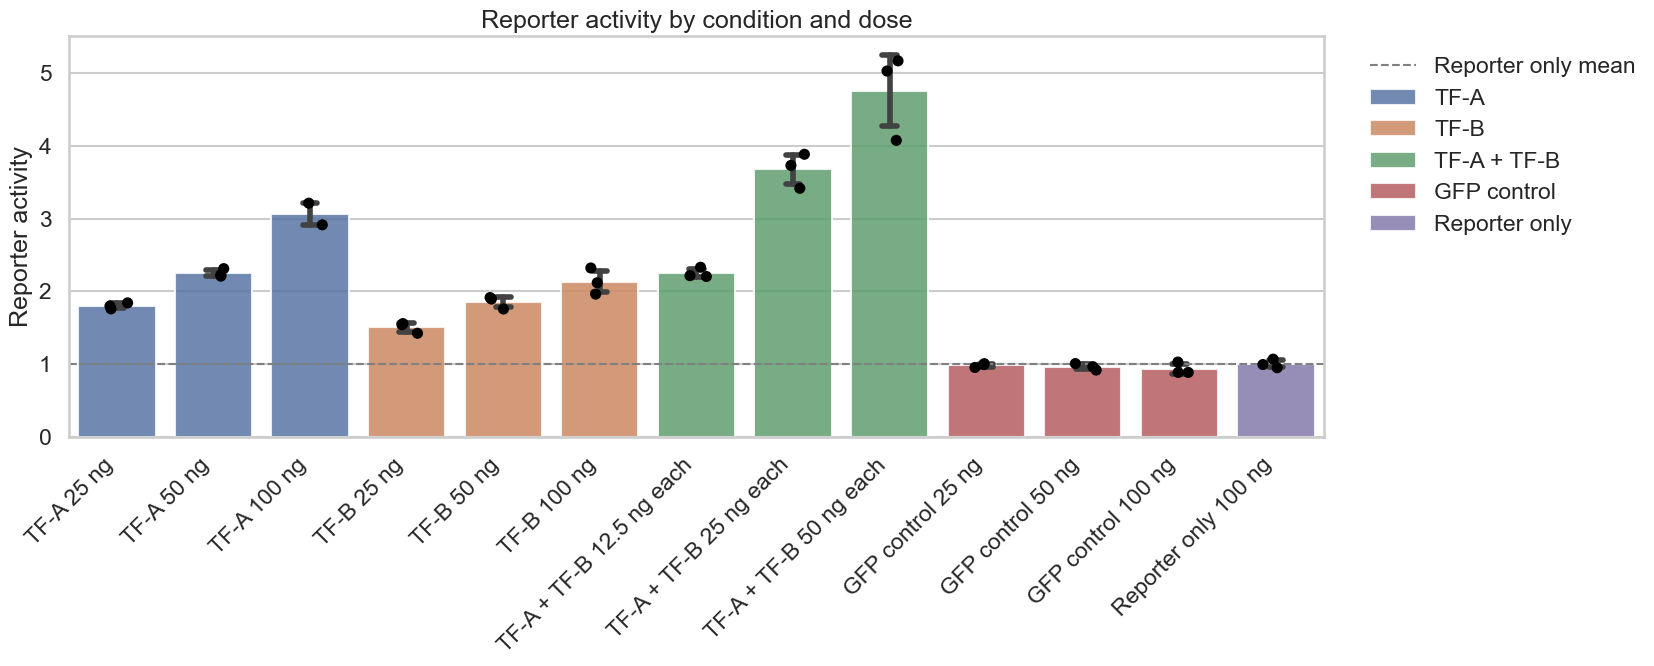

In [6]:
def bar_with_points(data, title, order=None, filename=None):
    fig, ax = plt.subplots(figsize=(max(8, 1.3 * data["label"].nunique()), 7))
    sns.barplot(data=data, x="label", y="value", hue="condition", order=order,
                dodge=False, capsize=0.15, **ERRORBAR_SD, alpha=0.85, ax=ax)
    sns.stripplot(data=data, x="label", y="value", order=order, color="black",
                  size=8, jitter=0.15, ax=ax)
    ax.axhline(baseline_mean, ls="--", color="grey", lw=1.5, label=f"{BASELINE} mean")
    ax.set(title=title, xlabel="", ylabel="Reporter activity")
    ax.tick_params(axis="x", rotation=45)
    plt.setp(ax.get_xticklabels(), ha="right")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    fig.tight_layout()
    if SAVE_FIGURES and filename:
        fig.savefig(Path(FIGURE_DIR) / filename, dpi=200, bbox_inches="tight")
    plt.show()

bar_with_points(tidy, "Reporter activity by condition and dose",
                order=layout["label"], filename="overview_bar.png")

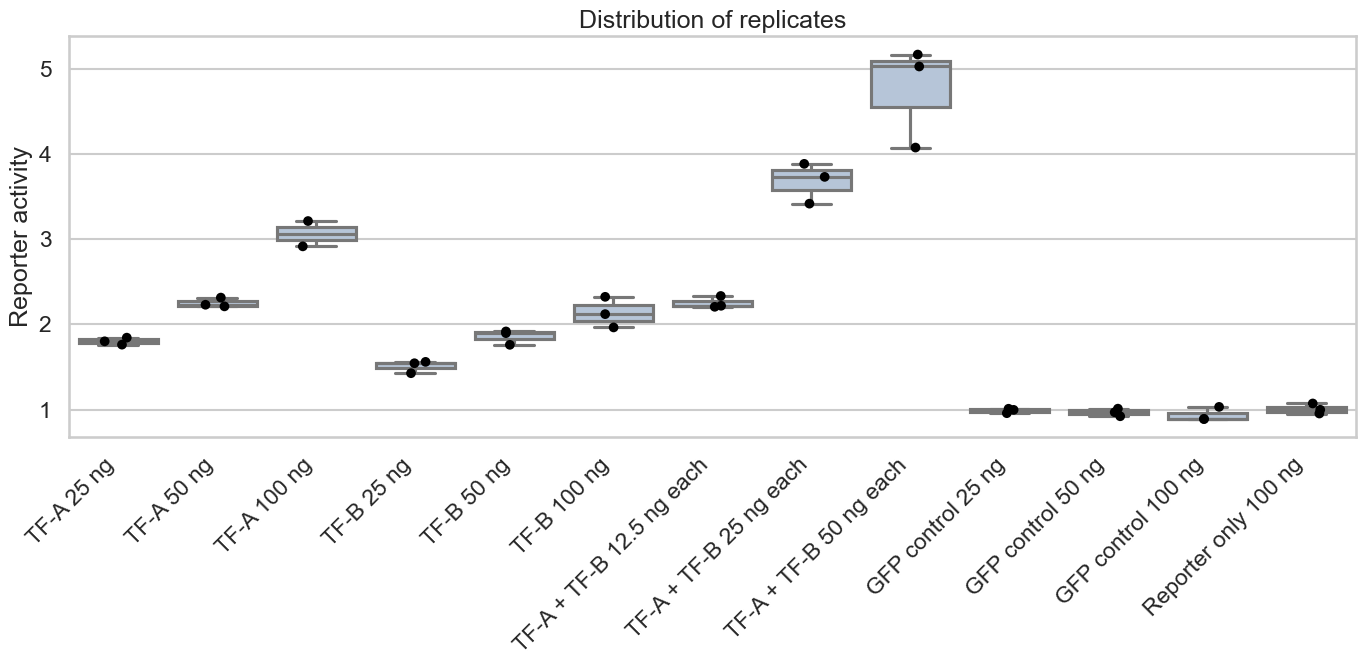

In [7]:
fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(data=tidy, x="label", y="value", order=layout["label"], color="lightsteelblue", ax=ax)
sns.stripplot(data=tidy, x="label", y="value", order=layout["label"], color="black", size=7, jitter=0.15, ax=ax)
ax.set(title="Distribution of replicates", xlabel="", ylabel="Reporter activity")
ax.tick_params(axis="x", rotation=45)
plt.setp(ax.get_xticklabels(), ha="right")
fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(Path(FIGURE_DIR) / "overview_boxplot.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Compare conditions at each dose level

Each plot puts every condition at the same dose level side by side, with the baseline condition included for reference.

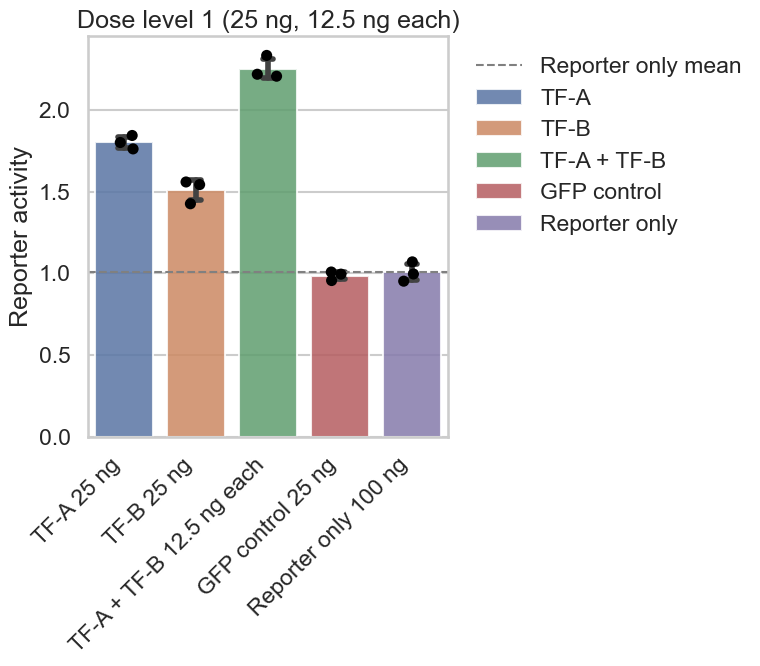

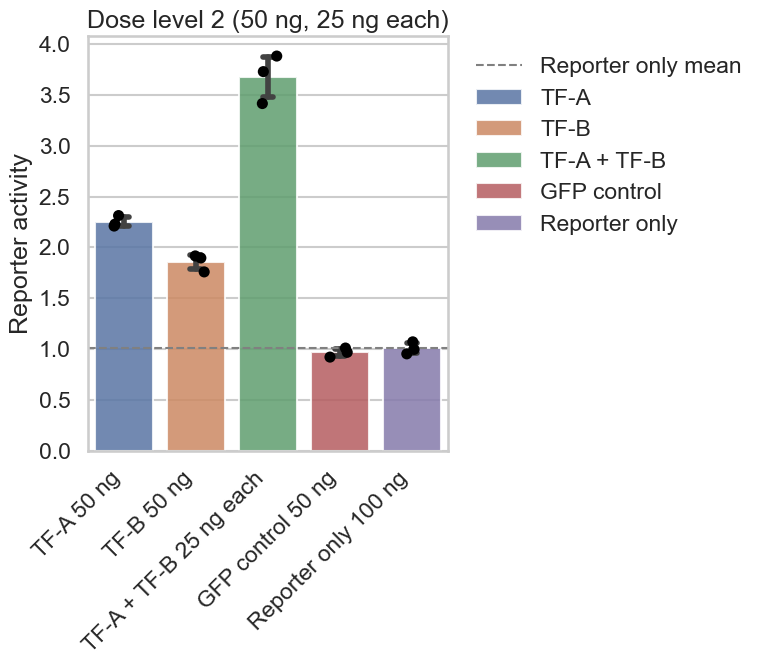

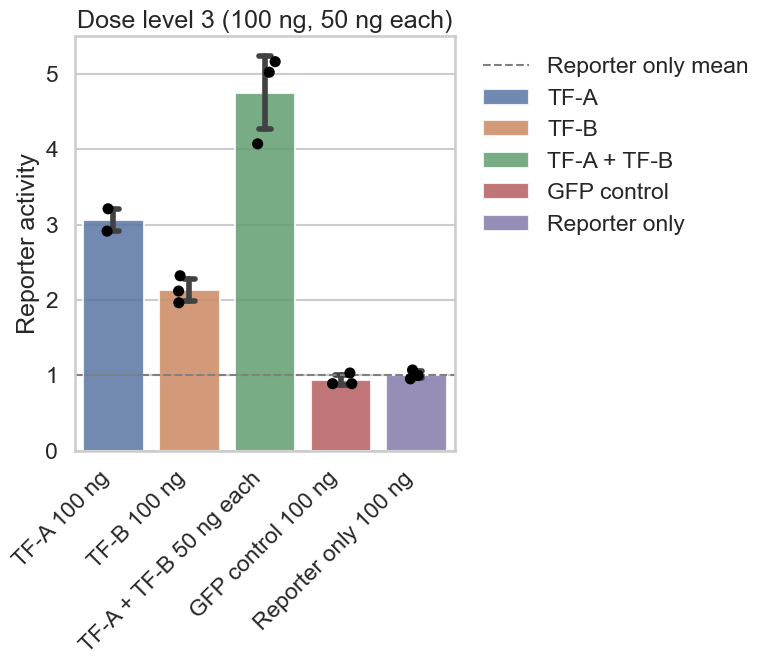

In [8]:
levels = sorted(tidy.loc[tidy["condition"] != BASELINE, "dose_level"].unique())
baseline_rows = tidy[tidy["condition"] == BASELINE]

for level in levels:
    subset = pd.concat([tidy[(tidy["dose_level"] == level) & (tidy["condition"] != BASELINE)], baseline_rows])
    order = list(dict.fromkeys(subset["label"]))
    names = ", ".join(subset.loc[subset["condition"] != BASELINE, "dose"].unique())
    bar_with_points(subset, f"Dose level {level} ({names})", order=order,
                    filename=f"dose_level_{level}.png")

## 6. Statistics vs. baseline

Welch's t-test (does not assume equal variances) comparing each condition/dose against the baseline.

> With only 2–3 replicates per group, p-values are rough indicators. For publication, consider a one-way ANOVA with a post-hoc test (e.g. Dunnett's) and correction for multiple comparisons.

In [9]:
baseline_values = baseline_rows["value"]
rows = []
for label, group in tidy[tidy["condition"] != BASELINE].groupby("label", sort=False):
    t, p = stats.ttest_ind(group["value"], baseline_values, equal_var=False)
    rows.append({"label": label, "n": len(group), "mean": group["value"].mean(),
                 "fold_vs_baseline": group["value"].mean() / baseline_mean,
                 "t": t, "p_value": p})

results = pd.DataFrame(rows)
results["significant (p < 0.05)"] = results["p_value"] < 0.05
results.round(4)

,label,n,mean,fold_vs_baseline,t,p_value,significant (p < 0.05)
0,TF-A 25 ng,3,1.8013,1.7888,19.0093,0.0001,True
1,TF-A 50 ng,3,2.2507,2.2350,26.5951,0.0000,True
2,TF-A 100 ng,2,3.0625,3.0412,13.4841,0.0364,True
3,TF-B 25 ng,3,1.5093,1.4988,9.2600,0.0009,True
4,TF-B 50 ng,3,1.8570,1.8441,14.1281,0.0003,True
5,TF-B 100 ng,3,2.1347,2.1198,10.2998,0.0046,True
6,TF-A + TF-B 12.5 ng each,3,2.2513,2.2357,23.4151,0.0000,True
7,TF-A + TF-B 25 ng each,3,3.6753,3.6498,18.8306,0.0016,True
8,TF-A + TF-B 50 ng each,3,4.7537,4.7206,10.8773,0.0078,True
9,GFP control 25 ng,3,0.9873,0.9805,-0.5202,0.6414,False


## 7. Export

Saves the tidy data, summary and statistics as CSV next to the figures.

In [10]:
out = Path(FIGURE_DIR)
tidy.to_csv(out / "tidy_data.csv", index=False)
summary.to_csv(out / "summary.csv", index=False)
results.to_csv(out / "statistics_vs_baseline.csv", index=False)
print("Saved to", out.resolve().name + "/:", sorted(p.name for p in out.iterdir()))

Saved to figures/: ['dose_level_1.png', 'dose_level_2.png', 'dose_level_3.png', 'overview_bar.png', 'overview_boxplot.png', 'statistics_vs_baseline.csv', 'summary.csv', 'tidy_data.csv']
